### Lab 3: Implementation of Gray Level Transformation using Python

1. Take a 5x6 NumPy array and apply negative image operations (calculate image bit dynamically). Convert the input and output NumPy array into an image and show them side by side in a subplot with a title.
2. Take a grayscale image and apply negative image operations (calculate image bit dynamically). Show input and output image side by side in a subplot with a title. Use PyPlot to plot the negative transformation curve (r on the x-axis and s on the y-axis).
3. Take a grayscale image and apply log transformation image operations (C = 1 and C = L/(log10(1+r))). Show input and output image side by side in subplot with title. Use pyplot to plot log transformation curve (r in x-axis and s in y-axis)
4. Take a grayscale image and apply gamma transformation image operations (y=0.2,y=0.4,y=0.6,y=1.0,y=1.5,y=2.5,y=5.0). Show input and output image side by side in a subplot with a title. Use PyPlot to plot the gamma transformation.

### Task 1

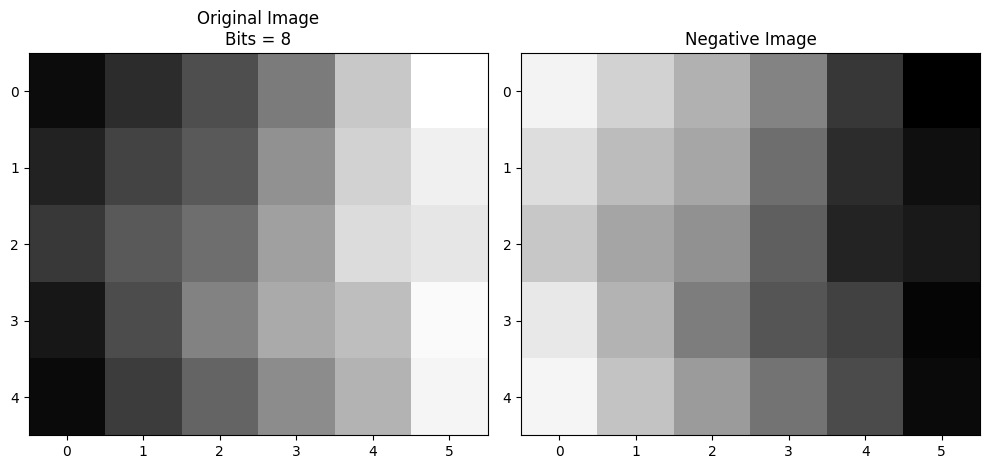

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array([
    [12, 45, 78, 123, 200, 255],
    [34, 67, 89, 145, 210, 240],
    [56, 90, 110, 160, 220, 230],
    [23, 76, 130, 170, 190, 250],
    [10, 60, 100, 140, 180, 245]
])

max_val = int(img.max())
bits = int(np.ceil(np.log2(max_val + 1)))
L = 2 ** bits

height, width = img.shape
negative_img = img.copy()

for i in range(height):
    for j in range(width):
        negative_img[i][j] = (L - 1) - img[i][j]

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=L-1)
plt.title(f"Original Image\nBits = {bits}")

plt.subplot(1, 2, 2)
plt.imshow(negative_img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Negative Image")

plt.tight_layout()
plt.show()

### Task 2

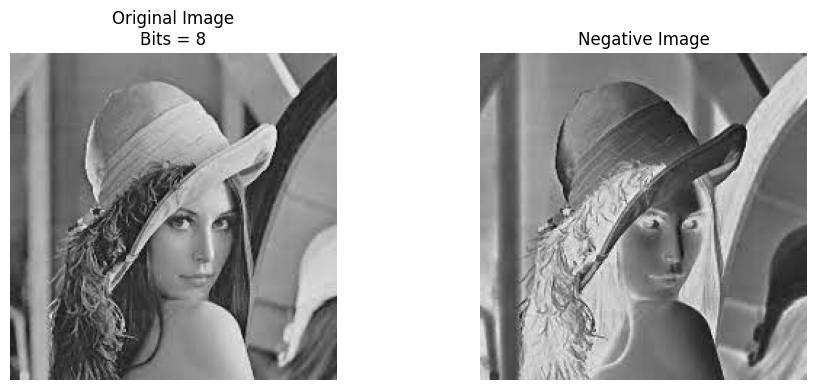

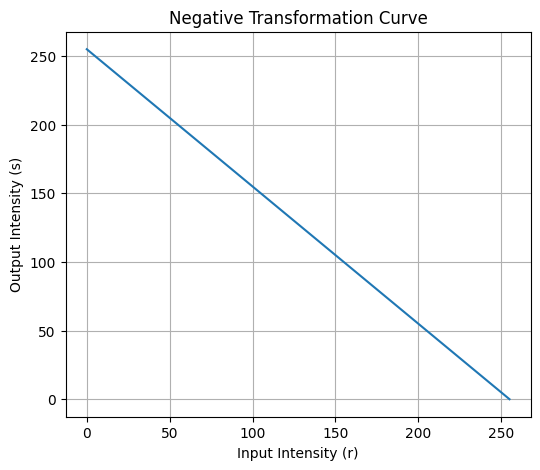

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./a.jpg", cv2.IMREAD_GRAYSCALE)

max_val = int(img.max())   

bits = 0
temp = max_val
while temp > 0:
    bits += 1
    temp //= 2

L = 2 ** bits

height, width = img.shape
negative_img = np.zeros_like(img)

for i in range(height):
    for j in range(width):
        negative_img[i][j] = (L - 1) - img[i][j]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=L-1)
plt.title(f"Original Image\nBits = {bits}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(negative_img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Negative Image")
plt.axis('off')

plt.tight_layout()
plt.show()

r = np.arange(0, L)
s = (L - 1) - r

plt.figure(figsize=(6,5))
plt.plot(r, s)
plt.title("Negative Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.grid(True)
plt.show()

### Task 3

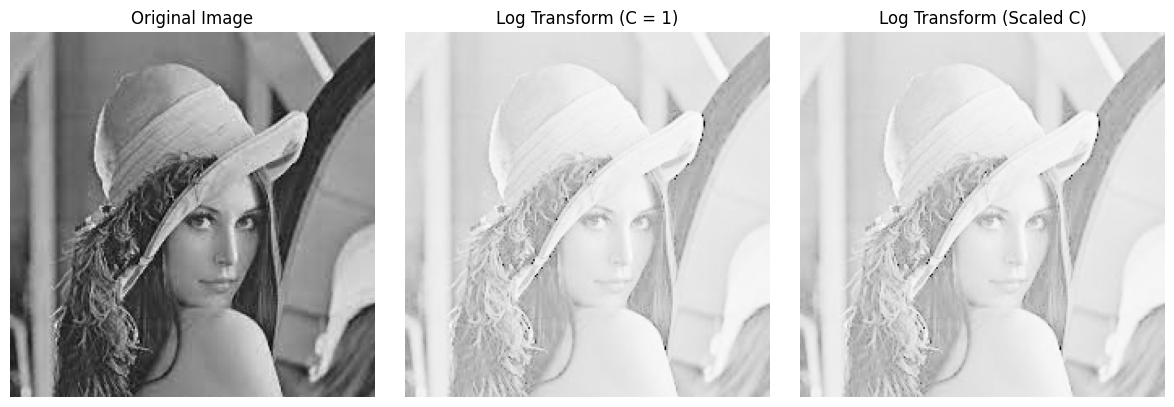

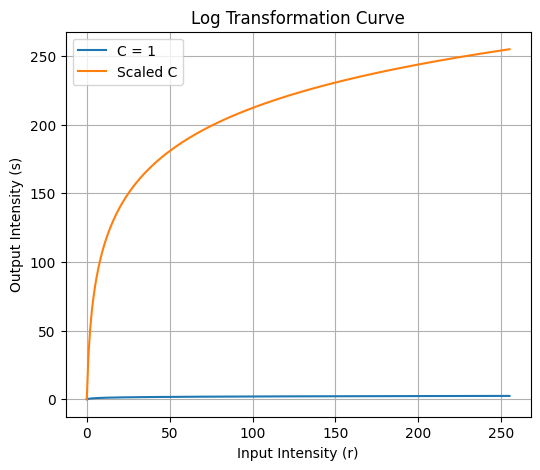

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("a.jpg", cv2.IMREAD_GRAYSCALE)

# Convert to float to prevent overflow
img_float = img.astype(np.float64)

# Dynamically calculate bit depth
max_val = int(img.max())
bits = 0
temp = max_val
while temp > 0:
    bits += 1
    temp //= 2

L = 2 ** bits

# Case 1: C = 1
log_img_c1 = np.zeros_like(img_float)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        log_img_c1[i][j] = np.log10(1 + img_float[i][j])

# Normalize to full intensity range
log_img_c1 = (log_img_c1 / log_img_c1.max()) * (L - 1)
log_img_c1 = log_img_c1.astype(np.uint8)

# Case 2: Scaled C
C = (L - 1) / np.log10(1 + max_val)

log_img_scaled = np.zeros_like(img_float)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        log_img_scaled[i][j] = C * np.log10(1 + img_float[i][j])

log_img_scaled = np.clip(log_img_scaled, 0, L-1).astype(np.uint8)

# Show Images
# --------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(log_img_c1, cmap='gray', vmin=0, vmax=L-1)
plt.title("Log Transform (C = 1)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_img_scaled, cmap='gray', vmin=0, vmax=L-1)
plt.title("Log Transform (Scaled C)")
plt.axis('off')

plt.tight_layout()
plt.show()

# --------------------------
# Plot Transformation Curve
# --------------------------
r = np.arange(0, L)
s1 = np.log10(1 + r)
s2 = C * np.log10(1 + r)

plt.figure(figsize=(6,5))
plt.plot(r, s1, label="C = 1")
plt.plot(r, s2, label="Scaled C")
plt.title("Log Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.legend()
plt.grid(True)
plt.show()

### Task 4

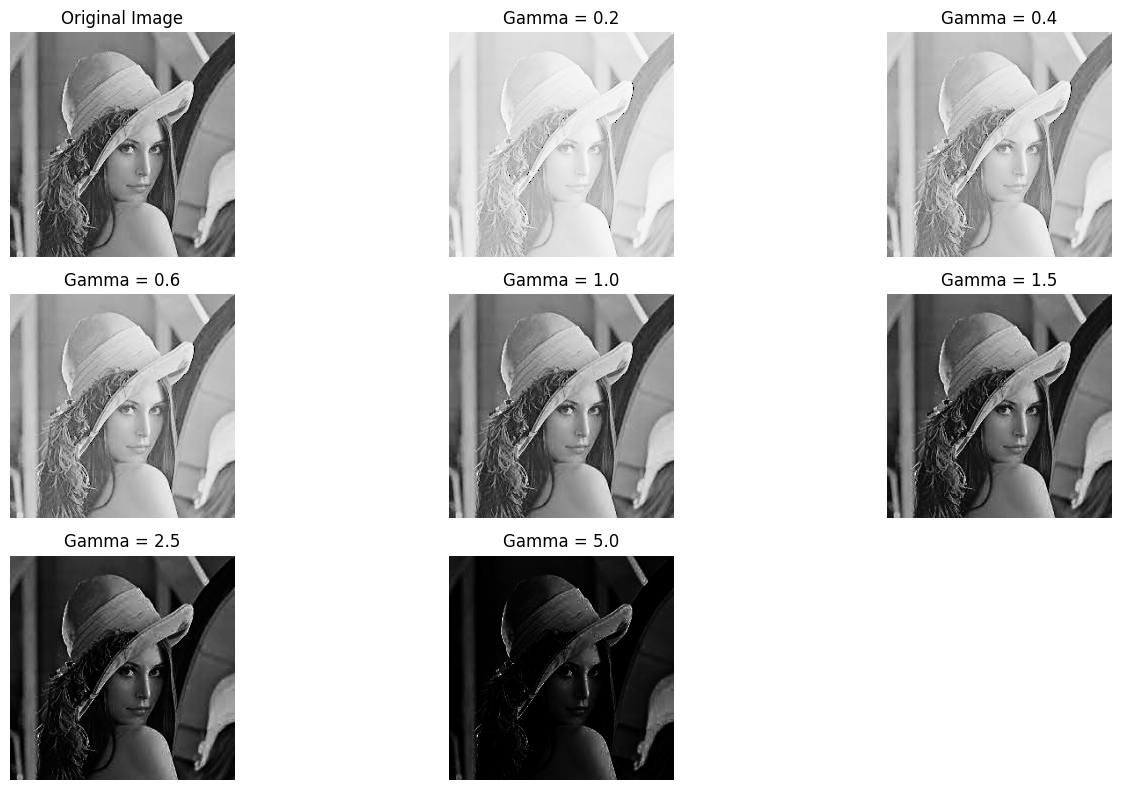

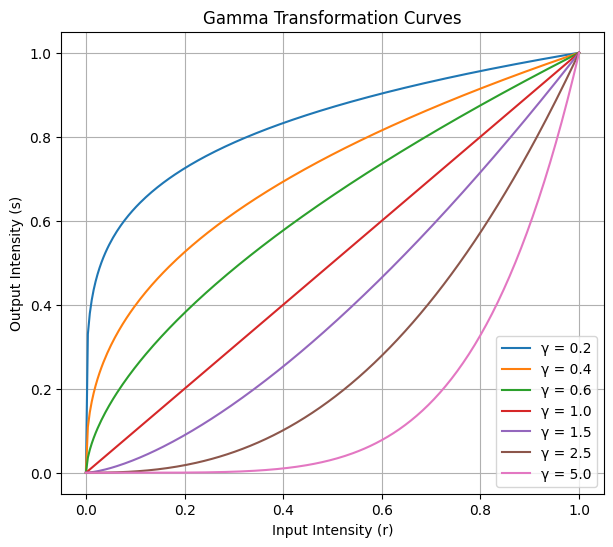

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("a.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found!")
    exit()

# Convert to float 
img_float = img.astype(np.float64)

# Bit depth
L = 256  # For 8-bit grayscale

gammas = [0.2, 0.4, 0.6, 1.0, 1.5, 2.5, 5.0]
gamma_images = []

# Apply gamma transformation
for g in gammas:
    gamma_img = np.zeros_like(img_float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            r = img_float[i][j] / (L - 1)   # Normalize
            s = (L - 1) * (r ** g)
            gamma_img[i][j] = s

    gamma_img = np.clip(gamma_img, 0, L-1).astype(np.uint8)
    gamma_images.append(gamma_img)

# -----------------------------
# Show Images
# -----------------------------
plt.figure(figsize=(14,8))

plt.subplot(3,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

for idx, g in enumerate(gammas):
    plt.subplot(3,3,idx+2)
    plt.imshow(gamma_images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f"Gamma = {g}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Plot Gamma Curves
# -----------------------------
r = np.linspace(0, 1, 256)

plt.figure(figsize=(7,6))

for g in gammas:
    s = r ** g
    plt.plot(r, s, label=f"γ = {g}")

plt.title("Gamma Transformation Curves")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.legend()
plt.grid(True)
plt.show()